In [4]:
!pip install nltk pandas scikit-learn matplotlib seaborn streamlit

In [5]:
import nltk
nltk.download('movie_reviews')
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\TEST\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TEST\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\TEST\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [6]:
import pandas as pd
import random
from nltk.corpus import movie_reviews

documents = []
for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        text = movie_reviews.raw(fileid)
        label = 1 if category == 'pos' else 0
        documents.append({'text': text, 'label': label})

random.shuffle(documents)
df = pd.DataFrame(documents)
print(f"Total reviews: {len(df)}")
print(f"Positive: {df['label'].sum()} | Negative: {len(df) - df['label'].sum()}")
df.head()

Total reviews: 2000
Positive: 1000 | Negative: 1000


,text,label
0,perhaps if the impostors didn't have so much g...,0
1,"darren ( jason biggs ) , wayne ( steve zahn ) ...",0
2,"if anything , "" stigmata "" should be taken as ...",0
3,i read the new yorker magazine and i enjoy som...,0
4,"by phil curtolo "" madonna - antonio banderas -...",0


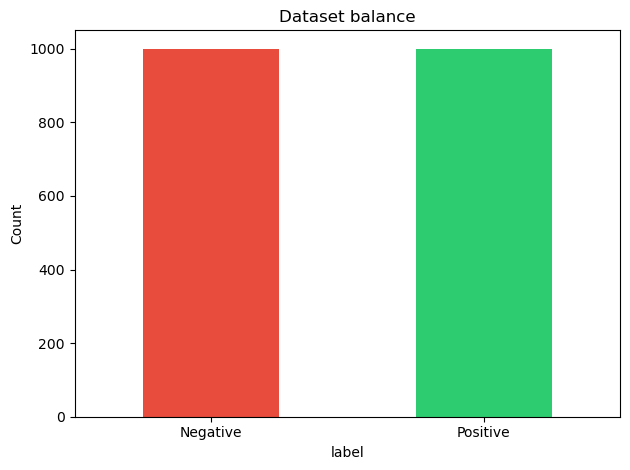

In [7]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='none')
plt.xticks([0, 1], ['Negative', 'Positive'], rotation=0)
plt.title('Dataset balance')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [8]:
sample = df[df['label'] == 1].iloc[0]['text']
print("POSITIVE REVIEW SAMPLE:")
print(sample[:500], "...")

POSITIVE REVIEW SAMPLE:
billy bob thornton , who had a sudden rise to fame with 1996's sling blade after spending years as a virtually unknown actor and writer , is becoming one of the most versatile - and most accomplished - american actors around at the moment . 
as jacob , the simple but at times very bright loser brother of bill paxton's hank , thornton gives a performance which should leave an indelible mark on all but the most hardened viewers . 
three men , hank ( paxton ) , jacob ( thornton ) and their friend l ...


In [9]:
df.to_csv('reviews.csv', index=False)
print("reviews.csv")

reviews.csv


In [10]:
import pandas as pd
df = pd.read_csv('reviews.csv')
print(f"Loaded {len(df)} reviews")
df.head()

Loaded 2000 reviews


,text,label
0,perhaps if the impostors didn't have so much g...,0
1,"darren ( jason biggs ) , wayne ( steve zahn ) ...",0
2,"if anything , "" stigmata "" should be taken as ...",0
3,i read the new yorker magazine and i enjoy som...,0
4,"by phil curtolo "" madonna - antonio banderas -...",0


In [11]:
import re
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
print(f"Total stopwords: {len(stop_words)}")
print(list(stop_words)[:10])

Total stopwords: 198
['it', 'in', 'has', 'more', 'my', 'why', 'shan', "we've", 'your', 'themselves']


In [12]:
def clean_text(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # 4. Remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

# Test it on a sample
sample = "This movie was GREAT!! I loved it so much... 10/10 would watch again."
print("Before:", sample)
print("After: ", clean_text(sample))

Before: This movie was GREAT!! I loved it so much... 10/10 would watch again.
After:  movie great loved much would watch


####  Apply cleaning to all reviews

In [13]:
df['clean_text'] = df['text'].apply(clean_text)

print("Original text:")
print(df['text'].iloc[0][:200])
print("\nCleaned text:")
print(df['clean_text'].iloc[0][:200])

Original text:
perhaps if the impostors didn't have so much going for it , it wouldn't have been such a tremendous disappointment . 
written , directed , and produced by one of its two stars , stanley tucci , whose 

Cleaned text:
perhaps impostors didnt much going wouldnt tremendous disappointment written directed produced one two stars stanley tucci whose last picture indie smash hit big night impostors almost never catches f


#### Check average word count before vs after

In [14]:
df['original_words'] = df['text'].apply(lambda x: len(x.split()))
df['clean_words']    = df['clean_text'].apply(lambda x: len(x.split()))

print(f"Avg words BEFORE cleaning: {df['original_words'].mean():.0f}")
print(f"Avg words AFTER  cleaning: {df['clean_words'].mean():.0f}")
print(f"Noise removed: {(1 - df['clean_words'].mean()/df['original_words'].mean())*100:.1f}%")

Avg words BEFORE cleaning: 746
Avg words AFTER  cleaning: 349
Noise removed: 53.3%


#### Visualize most common words

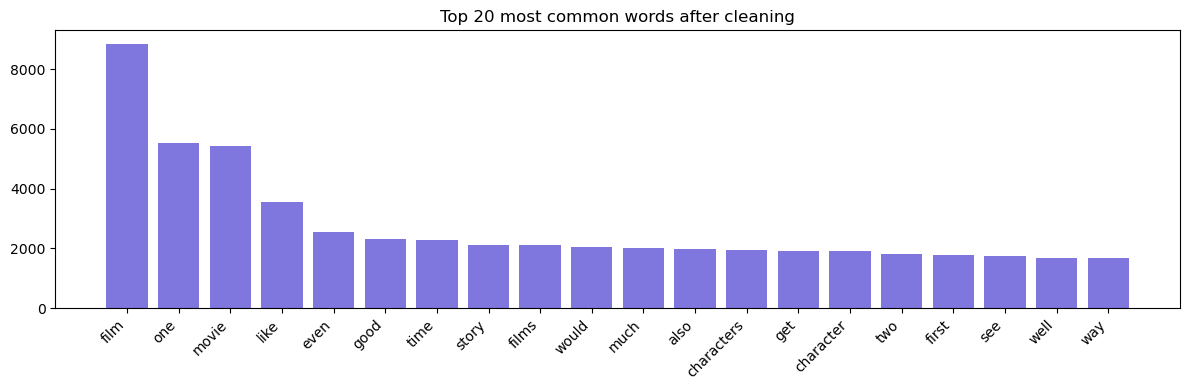

In [15]:
from collections import Counter
import matplotlib.pyplot as plt

all_words = ' '.join(df['clean_text']).split()
common = Counter(all_words).most_common(20)

words, counts = zip(*common)
plt.figure(figsize=(12, 4))
plt.bar(words, counts, color='#7F77DD', edgecolor='none')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 most common words after cleaning')
plt.tight_layout()
plt.show()

#### TF-IDF Vectorization 

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])
y = df['label'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Each review is now a vector of {X.shape[1]} numbers")
print(f"Labels shape: {y.shape}")

Feature matrix shape: (2000, 5000)
Each review is now a vector of 5000 numbers
Labels shape: (2000,)


#### Peek at top TF-IDF words

In [17]:
feature_names = vectorizer.get_feature_names_out()
print("Sample TF-IDF features (first 20 words in vocabulary):")
print(list(feature_names[:20]))

print("\nSample TF-IDF scores for review #1 (top 10 words):")
import numpy as np
row = X[0].toarray()[0]
top_indices = row.argsort()[-10:][::-1]
for i in top_indices:
    print(f"  {feature_names[i]:<20} score: {row[i]:.4f}")

Sample TF-IDF features (first 20 words in vocabulary):
['abandon', 'abandoned', 'abilities', 'ability', 'able', 'aboard', 'absence', 'absent', 'absolute', 'absolutely', 'absurd', 'abuse', 'abyss', 'academy', 'accent', 'accents', 'accept', 'acceptable', 'accepts', 'accident']

Sample TF-IDF scores for review #1 (top 10 words):
  platt                score: 0.1949
  arthur               score: 0.1885
  alfred               score: 0.1871
  stanley              score: 0.1775
  oliver               score: 0.1610
  allen                score: 0.1539
  everyone             score: 0.1417
  bad                  score: 0.1366
  steve                score: 0.1344
  actors               score: 0.1217


####  Save for next notebook

In [18]:
import pickle

with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

import scipy.sparse
scipy.sparse.save_npz('X_features.npz', X)
import numpy as np
np.save('y_labels.npy', y)

print("Saved vectorizer.pkl, X_features.npz, y_labels.npy")
print("Ready for Step 3: Model Training!")

Saved vectorizer.pkl, X_features.npz, y_labels.npy
Ready for Step 3: Model Training!


#### Train/Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 1600
Testing  samples : 400


#### Train Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression
import time

start = time.time()
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
end = time.time()

print(f"Training done in {end - start:.2f} seconds")
print(f"Training accuracy: {lr_model.score(X_train, y_train)*100:.2f}%")
print(f"Testing  accuracy: {lr_model.score(X_test,  y_test)*100:.2f}%")

Training done in 0.16 seconds
Training accuracy: 96.31%
Testing  accuracy: 85.25%


#### Train Naive Bayes (for comparison) 

In [21]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

print(f"Naive Bayes training accuracy: {nb_model.score(X_train, y_train)*100:.2f}%")
print(f"Naive Bayes testing  accuracy: {nb_model.score(X_test,  y_test)*100:.2f}%")

Naive Bayes training accuracy: 92.62%
Naive Bayes testing  accuracy: 81.25%


#### Full Evaluation Report 

In [22]:
from sklearn.metrics import classification_report

lr_preds = lr_model.predict(X_test)

print("=" * 45)
print("   LOGISTIC REGRESSION — FULL REPORT")
print("=" * 45)
print(classification_report(y_test, lr_preds, target_names=['Negative', 'Positive']))

   LOGISTIC REGRESSION — FULL REPORT
              precision    recall  f1-score   support

    Negative       0.87      0.81      0.84       192
    Positive       0.84      0.89      0.86       208

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



#### Confusion Matrix

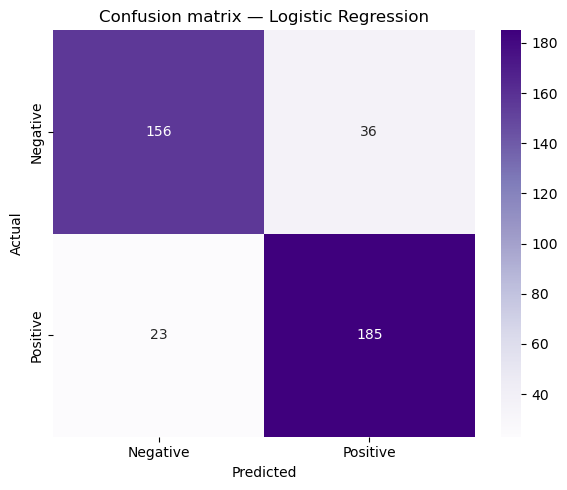

Correctly classified : 341
Wrongly  classified  : 59


In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion matrix — Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"Correctly classified : {cm[0][0] + cm[1][1]}")
print(f"Wrongly  classified  : {cm[0][1] + cm[1][0]}")

 ####  Compare both models visually

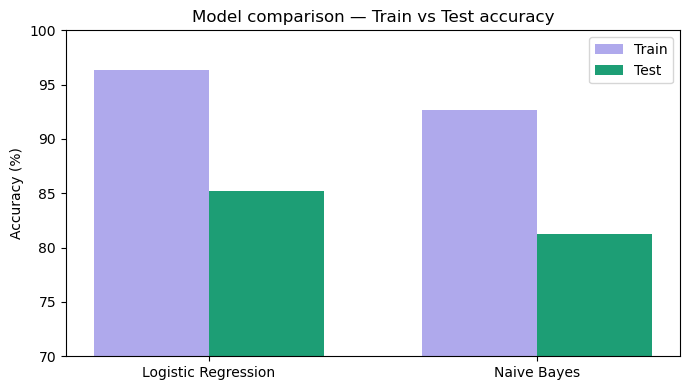

In [24]:
models     = ['Logistic Regression', 'Naive Bayes']
train_accs = [lr_model.score(X_train, y_train)*100,
              nb_model.score(X_train, y_train)*100]
test_accs  = [lr_model.score(X_test, y_test)*100,
              nb_model.score(X_test, y_test)*100]

x = range(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - width/2 for i in x], train_accs, width, label='Train', color='#AFA9EC', edgecolor='none')
ax.bar([i + width/2 for i in x], test_accs,  width, label='Test',  color='#1D9E75', edgecolor='none')

ax.set_ylim(70, 100)
ax.set_xticks(list(x))
ax.set_xticklabels(models)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model comparison — Train vs Test accuracy')
ax.legend()
plt.tight_layout()
plt.show()

#### Top words driving Positive / Negative predictions

In [25]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
coefs = lr_model.coef_[0]

top_positive = np.argsort(coefs)[-15:][::-1]
top_negative = np.argsort(coefs)[:15]

print("Top 15 words pushing POSITIVE prediction:")
for i in top_positive:
    print(f"  {feature_names[i]:<20} score: {coefs[i]:.3f}")

print("\nTop 15 words pushing NEGATIVE prediction:")
for i in top_negative:
    print(f"  {feature_names[i]:<20} score: {coefs[i]:.3f}")

Top 15 words pushing POSITIVE prediction:
  great                score: 1.609
  life                 score: 1.573
  also                 score: 1.320
  excellent            score: 1.130
  family               score: 1.108
  well                 score: 1.060
  hilarious            score: 1.059
  jackie               score: 0.982
  world                score: 0.975
  job                  score: 0.972
  terrific             score: 0.965
  perfectly            score: 0.957
  quite                score: 0.957
  cameron              score: 0.916
  many                 score: 0.885

Top 15 words pushing NEGATIVE prediction:
  bad                  score: -3.178
  worst                score: -1.884
  plot                 score: -1.672
  boring               score: -1.616
  nothing              score: -1.470
  supposed             score: -1.410
  theres               score: -1.386
  waste                score: -1.342
  unfortunately        score: -1.313
  script               score: -1.274
  stu

#### Test on your own sentences!

In [26]:
def predict_sentiment(text):
    cleaned   = clean_text(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = lr_model.predict(vectorized)[0]
    confidence = lr_model.predict_proba(vectorized)[0]

    label = "POSITIVE" if prediction == 1 else "NEGATIVE"
    score = confidence[prediction] * 100

    print(f"Text       : {text}")
    print(f"Sentiment  : {label}")
    print(f"Confidence : {score:.1f}%")
    print("-" * 45)

# Try these out!
predict_sentiment("This movie was absolutely amazing, I loved every minute!")
predict_sentiment("Terrible film, complete waste of time. Very boring.")
predict_sentiment("It was okay, nothing special but not bad either.")

Text       : This movie was absolutely amazing, I loved every minute!
Sentiment  : NEGATIVE
Confidence : 56.1%
---------------------------------------------
Text       : Terrible film, complete waste of time. Very boring.
Sentiment  : NEGATIVE
Confidence : 87.6%
---------------------------------------------
Text       : It was okay, nothing special but not bad either.
Sentiment  : NEGATIVE
Confidence : 83.5%
---------------------------------------------


In [27]:
import pickle

with open('model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

In [28]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("model.pkl saved!")

model.pkl saved!
